# Advanced Certification Programme in Agentic and Generative AI
## A Programme by IISc and TalentSprint
### Supplementary Notebook: Building a Simple Real-time Dashboard using Gradio

**(Ungraded)**

In [1]:
import gradio as gr
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime

In [2]:
# Example Data

data = {
    "Total students": 60,
    "Passed students": 47,
    "Failed students": 60-47
}
data

{'Total students': 60, 'Passed students': 47, 'Failed students': 13}

In [3]:
# Function to display data table

def get_data_table():
    global data
    return pd.DataFrame(list(data.items()), columns=["Metric", "Value"])

In [4]:
get_data_table()

,Metric,Value
0,Total students,60
1,Passed students,47
2,Failed students,13


In [5]:
# Function for Pie plot

def get_distribution_plot():
    global data

    pie_data = {
        "Passed": data["Passed students"],
        "Failed": data["Failed students"]
    }

    pie_data_colors = {
        "Passed": "#4CAF50",
        "Failed": "#F44336"
    }

    # Filter non-zero values
    filtered_data = {k: v for k, v in pie_data.items() if v > 0}

    if len(filtered_data) > 0:
        labels = list(filtered_data.keys())
        values = list(filtered_data.values())
        colors = [pie_data_colors[k] for k in filtered_data]

        fig, ax = plt.subplots()
        ax.pie(
            values,
            labels=labels,
            autopct="%1.1f%%",
            colors=colors,
            startangle=90
        )
        ax.set_title("Class Distribution")

        return fig

    else:
        return None


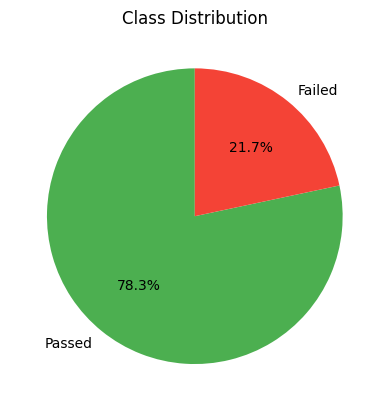

In [6]:
get_distribution_plot();

In [7]:
# Function for Line plot

history = []
prev_data = data  # store previous snapshot

# snapshot = {"Time": datetime.now().strftime("%H:%M:%S"), **data}
# history.append(snapshot)

def get_trend_plot():
    global history, prev_data, data

    # Check if data has changed
    # if list(prev_data.values()) != list(data.values()):
    snapshot = {"Time": datetime.now().strftime("%H:%M:%S"), **data}
    history.append(snapshot)
    prev_data = data   # update previous state

    # Keep last N points (optional)
    history = history[-20:]

    # Trend chart from history
    hist_df = pd.DataFrame(history)

    fig, ax = plt.subplots(figsize=(9, 5))
    metrics = [
        "Total students",
        "Passed students",
        "Failed students"
    ]

    for metric in metrics:
        ax.plot(hist_df["Time"], hist_df[metric], marker="o", label=metric)

    ax.set_title("Count Over Time")
    ax.set_xlabel("Time")
    ax.set_ylabel("Count")
    ax.legend()
    ax.grid(True)
    plt.xticks(rotation=45)
    plt.tight_layout()

    return fig


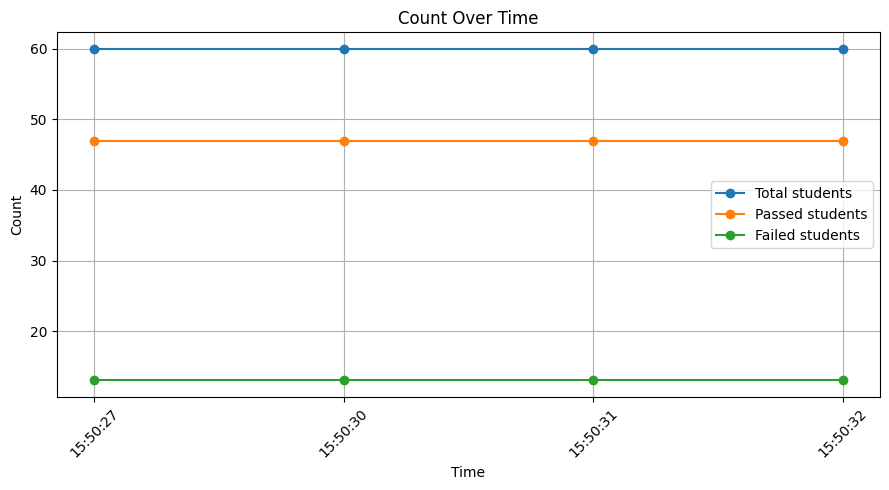

In [11]:
# Run this cell again and again to observe the change over time

get_trend_plot();

In [12]:
# Function for Bar plot

def get_category_plot():
    global data

    # Filter non-zero values (optional but recommended)
    filtered = {k: v for k, v in data.items() if v > 0}

    if len(filtered) == 0:
        return None

    categories = list(filtered.keys())
    values = list(filtered.values())

    fig, ax = plt.subplots(figsize=(6, 4))

    ax.bar(categories, values)

    ax.set_title("Category Distribution")
    ax.set_xlabel("Category")
    ax.set_ylabel("Count")
    ax.set_ylim(0, data['Total students'])
    ax.set_yticks(range(0, data['Total students'] + 1, 10))

    plt.xticks(rotation=30)
    plt.tight_layout()

    return fig

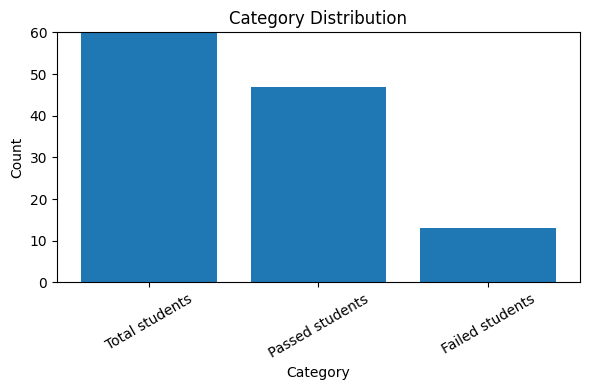

In [13]:
get_category_plot();

In [14]:
# Function to fetch the latest updated data

def fetch_updated_data():
    global history, prev_data, data

    df =  get_data_table()

    distribution_plot = get_distribution_plot()

    trend_plot = get_trend_plot()

    category_plot = get_category_plot()

    return df, distribution_plot, trend_plot, category_plot


In [17]:
# Create Gradio Interface

with gr.Blocks() as demo:
    gr.Markdown("<h1 style='text-align: center;'>Simple Dashboard (refreshes every 5 seconds)</h1>")

    with gr.Row():
        table = gr.DataFrame()
        incident_chart = gr.Plot(label="Incident Distribution")

    with gr.Row():
        trend_chart = gr.Plot(label="Trend Chart")
        category_chart = gr.Plot(label="Category")

    timer = gr.Timer(5)  # refresh every 5 seconds
    timer.tick(fetch_updated_data, outputs=[table, incident_chart, trend_chart, category_chart])


# Launch Gradio Interface
demo.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://527816f50f4fec37cb.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [18]:
# While the dashboard is up and running,
# change the values of your data and run this cell.
# The changes should be reflected in the Dashboard.

data = {
    "Total students": 60,
    "Passed students": 42,
    "Failed students": 60-42
}
data

{'Total students': 60, 'Passed students': 42, 'Failed students': 18}

---

<center>
$END$
</center>

---